# Assignment 9 | Time Series Classical

In [71]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
%pip install pytimetk
%pip install nbformat
import pytimetk as pytk

%pwd

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


'/Users/blove/PycharmProjects/deepLearning/Modlue9_tsclass'

## Loading in the Data

In [2]:
aus = pd.read_csv('/Users/blove/PycharmProjects/deepLearning/Data/aus-production.csv', delimiter=';')
def convert_quarter_to_date(quarter_str):
     year, q = quarter_str.split()
     month = (int(q[1]) - 1) * 3 + 1      
     return pd.Timestamp(f'{year}-{month:02d}-01')

aus['Quarter'] = aus['Quarter'].apply(convert_quarter_to_date)

aus.head()

aus.info()

aus.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Quarter      218 non-null    datetime64[ns]
 1   Beer         218 non-null    int64         
 2   Tobacco      194 non-null    float64       
 3   Bricks       198 non-null    float64       
 4   Cement       218 non-null    int64         
 5   Electricity  218 non-null    int64         
 6   Gas          218 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(4)
memory usage: 12.0 KB


,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
count,218,218.000000,194.000000,198.000000,218.000000,218.000000,218.000000
mean,1983-02-15 00:13:12.660550464,415.371560,6471.788660,405.494949,1422.628440,29409.821101,99.206422
min,1956-01-01 00:00:00,213.000000,3843.000000,187.000000,465.000000,3923.000000,5.000000
25%,1969-07-24 00:00:00,379.250000,5726.250000,349.000000,1051.250000,13079.500000,11.250000
50%,1983-02-15 00:00:00,422.000000,6583.500000,417.000000,1376.000000,27203.500000,105.000000
75%,1996-09-08 00:00:00,465.750000,7230.250000,475.000000,1736.000000,45547.750000,163.750000
max,2010-04-01 00:00:00,599.000000,8671.000000,589.000000,2612.000000,64067.000000,252.000000
std,NaN,85.880662,1068.085892,96.163131,503.095574,17731.372138,75.985377


## Beer Prod. vs Time Plot

In [3]:
help(pytk.plot.plot_time_series_regression)

Help on function plot_time_series_regression in module pytimetk.plot.plot_time_series_regression:

plot_time_series_regression(data: Union[pandas.core.frame.DataFrame, pandas.core.groupby.generic.DataFrameGroupBy], date_column: Union[str, Sequence[str], re.Pattern, Callable[[pandas.core.indexes.base.Index], Iterable[str]], NoneType], formula: str, show_summary: bool = False, model_kwargs: Optional[Dict[str, Any]] = None, **plot_kwargs: Any) -> plotly.graph_objs._figure.Figure
    Fit a linear regression using a formula and visualise observed vs fitted
    values over time using :func:`pytimetk.plot_timeseries`.
    
    Parameters
    ----------
    data : DataFrame or GroupBy
        Long-format time series data or grouped data via ``DataFrame.groupby``.
        Polars inputs are automatically converted to pandas.
    date_column : str or ColumnSelector
        Datetime column used on the x-axis.
    formula : str
        Patsy/Statsmodels formula passed to :func:`statsmodels.formula.

In [4]:
import pytimetk as pytk


pytk.plot_timeseries(
    aus, 
    date_column='Quarter',
    value_column='Beer',
    title='Beer Production vs Time'

)

### Differenced Plot - Beer

In [5]:
aus['Beer_diff'] = aus['Beer'].diff()

pytk.plot_timeseries(
    aus.dropna(),
    date_column='Quarter',
    value_column='Beer_diff',
    title='Differenced Beer Production'
)

**1a Response**
- Differencing eliminates the upward trend seen at the beginning of the first graph, however it does not elimnate the seasonality. The seasonality in both graphs is strong, with a low Q1 and a high Q4.

## Auto Correlation Plot - Beer

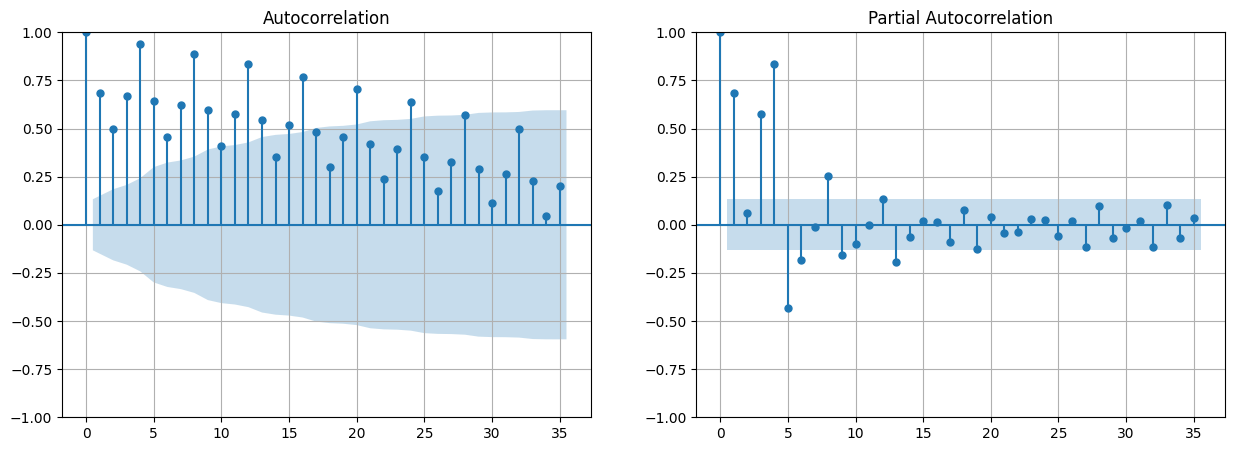

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plot_acf(aus["Beer"], ax=axs[0], lags=35)
axs[0].grid()

# Using partial auto correlation
plot_pacf(aus["Beer"], ax=axs[1], lags=35, method="ywm")
axs[1].grid()
plt.show()

**1b Response**
- The autocorrelation plot shows a strong seasonal pattern, especially at lags 4, 8, 12, etc.
- This would confirm seasonality in the beer production data
- The ACF also decays from lag 1, indicating a non-stationary, underlying trend.
- In the PCAF, we can see a strong spike at lag-1, suggesting an AR(1) effect, along with smaller seasonal spikes at lag 4.

## 1990 Subset Data - Beer (Training 7 Test split)

In [40]:
train_aus = aus[aus['Quarter'] < '1990-01-01']


y_beer = train_aus['Beer'].values


# 4 quarters per year, 3 years = 3 x 4 = 12 quarters
# These 12 rows will be used to check how good your forecasts are.

## Metrics/Models - Beer

### Baselines

In [54]:
%pip install statsforecast
from statsforecast.models import HistoricAverage, Naive, SeasonalNaive

# Mean model
mean_model = HistoricAverage()
mean_model = mean_model.fit(y=y_beer)
mean_pred = mean_model.predict(h=12)  # last 12 quarters
mean_pred = mean_pred['mean']
   

# Naive model
naive_model = Naive()
naive_model = naive_model.fit(y=y_beer)
naive_pred = naive_model.predict(h=12)
naive_pred = naive_pred['mean']


# Seasonal Naive model (quarterly seasonality = 4)
snaive_model = SeasonalNaive(season_length=4)
snaive_model = snaive_model.fit(y=y_beer)
snaive_pred = snaive_model.predict(h=12)
snaive_pred = snaive_pred['mean']

# Test Set
test = aus.tail(12)
y_test = test['Beer'].values

print("Mean method:",mean_pred,"\n\nNaive method:",naive_pred,"\n\nSeasonal naïve method:",snaive_pred)


Note: you may need to restart the kernel to use updated packages.
Mean method: [401.6103 401.6103 401.6103 401.6103 401.6103 401.6103 401.6103 401.6103
 401.6103 401.6103 401.6103 401.6103] 

Naive method: [567. 567. 567. 567. 567. 567. 567. 567. 567. 567. 567. 567.] 

Seasonal naïve method: [467. 439. 446. 567. 467. 439. 446. 567. 467. 439. 446. 567.]


### Mean Absolute Error

In [55]:
from sklearn.metrics import mean_absolute_error

mae_mean = mean_absolute_error(y_test, mean_pred)
mae_naive = mean_absolute_error(y_test, naive_pred)
mae_snaive = mean_absolute_error(y_test, snaive_pred)

print("MAE Results:")
print(f"Mean Model MAE:            {mae_mean:.2f}")
print(f"Naive Model MAE:           {mae_naive:.2f}")
print(f"Seasonal Naive Model MAE:  {mae_snaive:.2f}")


MAE Results:
Mean Model MAE:            30.38
Naive Model MAE:           143.42
Seasonal Naive Model MAE:  78.17


In [56]:
print("y_test shape:", y_test.shape)
print("mean_pred shape:", mean_pred.shape)
print("naive_pred shape:", naive_pred.shape)
print("snaive_pred shape:", snaive_pred.shape)

print("snaive_pred:", snaive_pred)


y_test shape: (12,)
mean_pred shape: (12,)
naive_pred shape: (12,)
snaive_pred shape: (12,)
snaive_pred: [467. 439. 446. 567. 467. 439. 446. 567. 467. 439. 446. 567.]


## Auto Arima Model - Beer

In [65]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

df_sf = aus[['Quarter', 'Beer']].copy()

df_sf['unique_id'] = 'beer_series'
df_sf = df_sf.rename(columns={'Quarter': 'ds', 'Beer': 'y'})

df_sf['ds'] = pd.to_datetime(df_sf['ds'])
df_sf['y'] = pd.to_numeric(df_sf['y'], errors='coerce')

models = [AutoARIMA(season_length=4)]

sf = StatsForecast(models=models, freq='Q', n_jobs=1)

sf_fitted = sf.fit(
    df=df_sf,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

df_forecast = sf_fitted.predict(h=12)
df_forecast


,unique_id,ds,AutoARIMA
0,beer_series,2010-06-30,410.230347
1,beer_series,2010-09-30,477.218781
2,beer_series,2010-12-31,412.710358
3,beer_series,2011-03-31,379.249603
4,beer_series,2011-06-30,400.510284
5,beer_series,2011-09-30,476.051514
6,beer_series,2011-12-31,411.711792
7,beer_series,2012-03-31,377.791809
8,beer_series,2012-06-30,400.549805
9,beer_series,2012-09-30,473.984070


## Tourism

In [66]:
tour = pd.read_csv('/Users/blove/PycharmProjects/deepLearning/Data/tourism.csv')
tour['Quarter'] = pd.to_datetime(tour['Quarter'])

tour.head()

tour.info()

tour.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24320 entries, 0 to 24319
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Quarter  24320 non-null  datetime64[ns]
 1   Region   24320 non-null  object        
 2   State    24320 non-null  object        
 3   Purpose  24320 non-null  object        
 4   Trips    24320 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 950.1+ KB


,Quarter,Trips
count,24320,24320.000000
mean,2007-11-15 22:30:00,70.896448
min,1998-01-01 00:00:00,0.000000
25%,2002-12-09 00:00:00,7.223910
50%,2007-11-16 00:00:00,28.134538
75%,2012-10-24 00:00:00,78.154410
max,2017-10-01 00:00:00,985.278401
std,NaN,118.763185


### Time Series - tourism


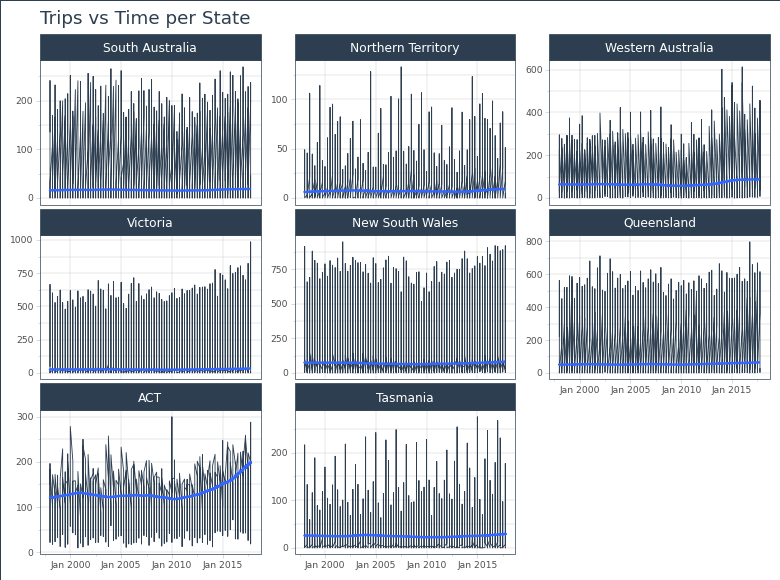

In [ ]:
tour.groupby('State').plot_timeseries(
    date_column='Quarter',
    value_column='Trips',
    facet_ncol=3,        # number of plots per row
    facet_scales='free_y',
    title='Trips vs Time per State',
    engine='matplotlib'  #
)

### Fitting Models - Tourism

In [75]:
# Prepare dataframe for StatsForecast
df_sf = tour.copy()

df_sf = df_sf.rename(columns={
    'Quarter': 'ds',
    'Trips': 'y',
    'State': 'unique_id'
})

df_sf['ds'] = pd.to_datetime(df_sf['ds'])
df_sf = df_sf[['unique_id', 'ds', 'y']]

In [76]:
models = [AutoARIMA(season_length=4)]  # quarterly

sf = StatsForecast(
    models=models,
    freq='Q',          # Quarterly data
    n_jobs=1
)

sf_fitted = sf.fit(
    df=df_sf,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

df_forecast = sf_fitted.predict(h=4)   # 4 quarters ahead
df_forecast


,unique_id,ds,AutoARIMA
0,ACT,2017-12-31,194.484249
1,ACT,2018-03-31,192.034594
2,ACT,2018-06-30,38.276183
3,ACT,2018-09-30,220.691984
4,New South Wales,2017-12-31,119.026979
5,New South Wales,2018-03-31,112.279685
6,New South Wales,2018-06-30,102.251601
7,New South Wales,2018-09-30,151.035262
8,Northern Territory,2017-12-31,13.897391
9,Northern Territory,2018-03-31,23.177955


### Plotting Actual & Forecast Models

In [77]:
df_plot = pd.concat([df_sf, df_forecast], ignore_index=True)


/Users/blove/PycharmProjects/deepLearning/.venv/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning:

geom_path: Removed 4 rows containing missing values.



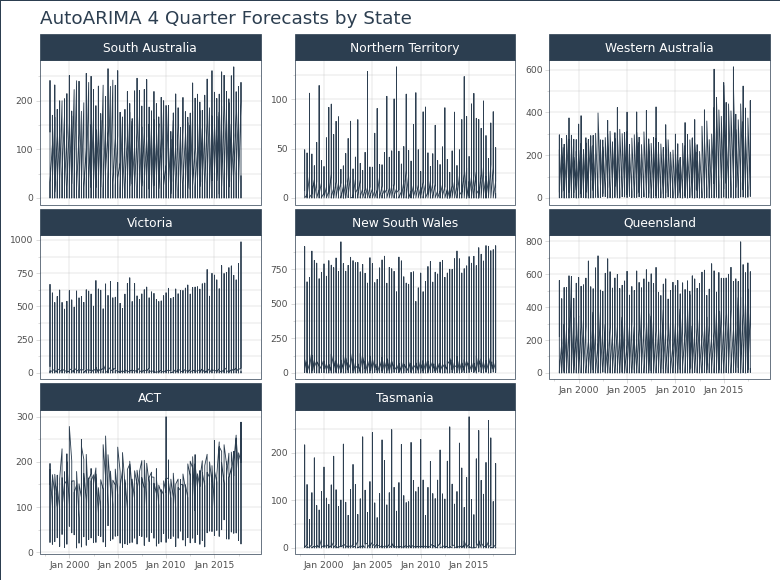

In [78]:
(
    df_plot
        .groupby('unique_id')
        .plot_timeseries(
            date_column='ds',
            value_column='y',
            facet_ncol=3,
            facet_scales='free_y',
            smooth=False,
            title='AutoARIMA 4 Quarter Forecasts by State',
            engine='matplotlib'
        )
)


### Results & Performance

Models produced by AutoARIMA were estimated independently for every state in the United States. They were used for forecasting the next four quarters. These projections consist of further continuation of the existing seasonal cycles in every state’s time series. Where there was intense seasonality along with a stable trend, the models performed well with AutoARIMA.

In those regions with more volatility or sudden structural changes (spikes or drops), the bands of the forecast will widen, which will indicate that predictions will not be entirely reliable. Of course, this is as it should be.

In general, AutoARIMA works best in states with:

- "seasonal patterns repeat consistently,
- trends are stable,
- noise is relatively low.

It is less effective in states with:

- inconsistent seasonal behavior,
- large shocks,
- rapidly changing patterns.

Faceted plots highlight variations in forecasting curves for different states, enabling the detection of regions suitable for ARIMA modeling and other models such as ETS, SeasonalNaive, that may forecast better.